In [8]:
# Imports
import pandas as pd
import boto3
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set view options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [3]:
def s3_parquet_files_to_df(bucket, prefix):
    """
    Convert all parquet files under a given S3 bucket and prefix to a singular Pandas dataframes

    Parameters
    ----------
    bucket: str
            S3 bucket
    prefix: str
            Prefix for object within given S3 bucket
    output_filepath: str
                     Local folder to store downloaded files from S3 bucket + prefix

    Returns
    -------
    pandas.DataFrame
    Combined DataFrame containing data from all parquet files downloaded from S3 bucket + prefix

    """

    # Initialize S3 Client
    s3_client = boto3.client('s3')

    # Grab connection to bucket & prefix
    response = s3_client.list_objects_v2(Bucket = bucket, Prefix = prefix)

    # Initializing empty list for individual dataframes
    df_downloaded = []

    # Loop through each object in bucket + prefix
    for obj in response.get('Contents', []):

        # Initializing empty DataFrame of data for each file
        df_file = pd.DataFrame()

        # Get key of object
        key = obj['Key']

        # If files in folder are not .parquet, then skip
        if not key.endswith('.parquet'):
            continue

        try:
            # Get filename of obj & S3 filepath of obj
            s3_filepath = f"s3://{bucket}/{key}"

            # Store file in dataframe
            df_file = pd.read_parquet(s3_filepath)

            # Append list of dataframes
            df_downloaded.append(df_file)

        except Exception as e:
            print(f"File <s3://{bucket}/{key}> was not able to be pulled from the given S3 bucket! An error has occurred: {e}")

        # Concatenate all individual dataframes into a singular one
        if df_downloaded:
            df = pd.concat(df_downloaded, ignore_index = True)
        else:
            df = pd.DataFrame()

    return df

In [4]:
df = s3_parquet_files_to_df(bucket = 'dsan6000-sc2641', prefix = 'wikipedia-hourly')

In [5]:
df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,user,bot,notify_url,minor,length,revision,server_url,server_name,server_script_path,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,Leeapp,False,https://en.wikipedia.org/w/index.php?diff=1372...,True,"{'old': 19355, 'new': 19357}","{'old': 1372533920, 'new': 1372536665}",https://en.wikipedia.org,en.wikipedia.org,/w,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,Birjeta01,False,https://en.wikipedia.org/w/index.php?diff=1372...,False,"{'old': 11817, 'new': 12062}","{'old': 1372533558, 'new': 1372536668}",https://en.wikipedia.org,en.wikipedia.org,/w,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,WMSR,False,https://en.wikipedia.org/w/index.php?diff=1372...,False,"{'old': 45669, 'new': 45711}","{'old': 1372536614, 'new': 1372536662}",https://en.wikipedia.org,en.wikipedia.org,/w,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,A.Cython,False,https://en.wikipedia.org/w/index.php?diff=1372...,False,"{'old': 27422, 'new': 27533}","{'old': 1372534451, 'new': 1372536669}",https://en.wikipedia.org,en.wikipedia.org,/w,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,~2026-47482-25,False,https://en.wikipedia.org/w/index.php?diff=1372...,False,"{'old': 13977, 'new': 13980}","{'old': 1371951821, 'new': 1372536676}",https://en.wikipedia.org,en.wikipedia.org,/w,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119708 entries, 0 to 119707
Data columns (total 29 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   datetime            119708 non-null  str    
 1   $schema             119708 non-null  str    
 2   meta                119708 non-null  str    
 3   id                  119707 non-null  float64
 4   type                119708 non-null  str    
 5   namespace           119708 non-null  int64  
 6   title               119708 non-null  str    
 7   title_url           119708 non-null  str    
 8   comment             99535 non-null   str    
 9   timestamp           119708 non-null  int64  
 10  user                119708 non-null  str    
 11  bot                 119708 non-null  bool   
 12  notify_url          115307 non-null  str    
 13  minor               115307 non-null  object 
 14  length              115307 non-null  str    
 15  revision            115307 non-null  str    


In [7]:
display(df['datetime'].min())
display(df['datetime'].max())

'2026-09-01 04:00:01'

'2026-09-02 03:44:54'

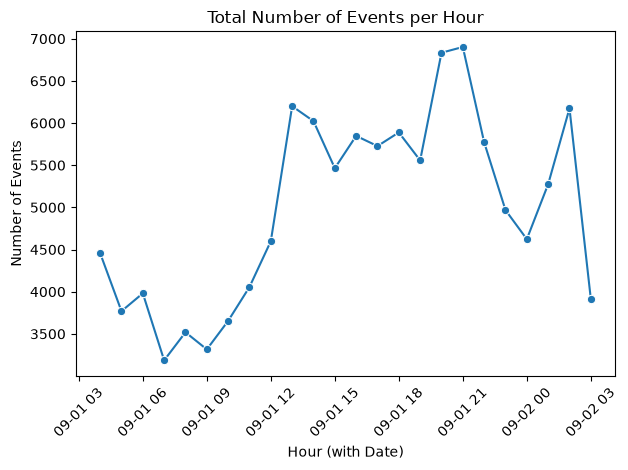

In [9]:
#### Plot 1: Visualize the total number of events per hour

# Convert timestamp to hour
df['datetime'] = pd.to_datetime(df['datetime'], format = '%Y-%m-%d %H:%M:%S')
df['date_hour'] = df['datetime'].dt.floor('h')

# Count of events per hour
events_ct = df.groupby('date_hour')['id'].count().reset_index(name = 'events_per_hour')

# Plot count of events per hour
sns.lineplot(data = events_ct, x = 'date_hour', y = 'events_per_hour', marker = 'o')
plt.xticks(rotation = 45)
plt.xlabel('Hour (with Date)')
plt.ylabel('Number of Events')
plt.title('Total Number of Events per Hour')
plt.tight_layout()
plt.savefig('images/hourly_events.png')
plt.savefig('images/hourly_events.svg')
plt.show()

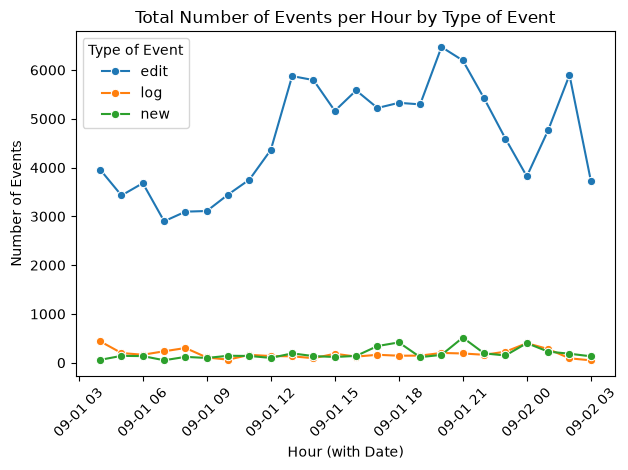

In [13]:
#### Plot 2: Visualize the hourly event counts by type

# Count of events per hour
events_ct_2 = df.groupby(['date_hour', 'type'])['id'].count().reset_index(name = 'events_per_hour')

# Plot count of events per hour
sns.lineplot(data = events_ct_2, x = 'date_hour', y = 'events_per_hour', marker = 'o', hue = 'type')
plt.xticks(rotation = 45)
plt.xlabel('Hour (with Date)')
plt.ylabel('Number of Events')
plt.legend(title = 'Type of Event')
plt.title('Total Number of Events per Hour by Type of Event')
plt.tight_layout()
plt.savefig('images/events-by-type.png')
plt.savefig('images/events-by-type.svg')
plt.show()